In [ ]:
!pip install ultralytics

In [ ]:
!pip install -q opencv_jupyter_ui

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 kB 9.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import dataclasses
import glob
import matplotlib.pyplot as plt
import os
import random
import ultralytics
from ultralytics import YOLO
import shutil
import opencv_jupyter_ui as jcv2
import time

In [ ]:
# Enable 3rd party widgets to show the video
from google.colab import output

output.enable_custom_widget_manager()

In [ ]:
# Download the dataset.
!kaggle datasets download -d iasadpanwhar/football-player-detection-yolov8

Dataset URL: https://www.kaggle.com/datasets/iasadpanwhar/football-player-detection-yolov8
License(s): apache-2.0
100% 1.08G/1.08G [00:19<00:00, 134MB/s]
100% 1.08G/1.08G [00:19<00:00, 61.1MB/s]


In [ ]:
!unzip football-player-detection-yolov8.zip

# Visualization

In [ ]:
def read_image(path: str):
    """Reads the image in RGB instead of BGR."""
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def show_random_image(split: str):
    """Shows a random image from the given dataset."""
    paths = glob.glob(f"/content/football_players_detection/football_players_detection/{split}/images/*.jpg")
    image = read_image(random.choice(paths))
    plt.imshow(image)
    plt.show()

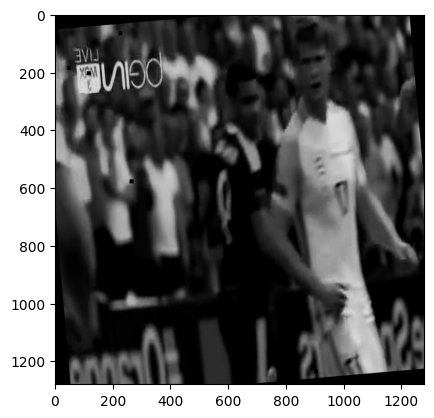

In [ ]:
show_random_image("train")

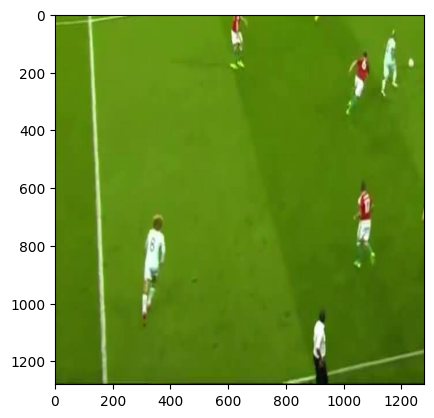

In [ ]:
show_random_image("valid")

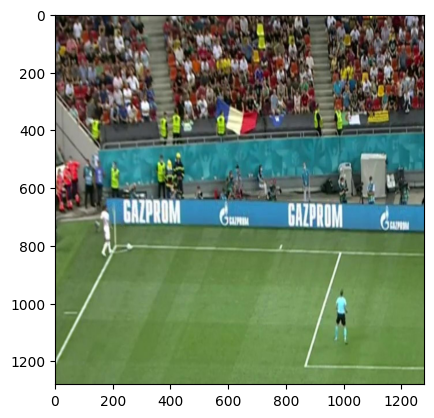

In [ ]:
show_random_image("test")

In [ ]:
class_names = ("football", "player")

@dataclasses.dataclass
class Label:
    class_id: int
    x_center: float
    y_center: float
    width: float
    height: float

def read_label_file(path: str) -> list[Label]:
    """Reads the label file and returns a list of labels."""
    labels: list[Label] = []

    with open(path) as f:
        # Each line in the file follows the following pattern:
        # class_id x_center y_center width height
        for line in f:
            class_id, x_center, y_center, width, height = line.split(" ")
            label = Label(
                class_id=int(class_id),
                x_center=float(x_center),
                y_center=float(y_center),
                width=float(width),
                height=float(height),
            )
            labels.append(label)

    return labels

In [ ]:
def show_image_with_labels(image_path: str, label_path: str):
    """Shows the image and the detected objects in that image."""
    image = read_image(image_path)
    labels = read_label_file(label_path)

    image_height = image.shape[0]
    image_width = image.shape[1]

    plt.imshow(image)

    for label in labels:
        x = label.x_center * image_width
        y = label.y_center * image_height
        width = label.width * image_width
        height = label.height * image_height

        x_min = x - width / 2
        x_max = x + width / 2
        y_min = y - height / 2
        y_max = y + height / 2

        plt.plot(
            (x_min, x_min, x_max, x_max, x_min),
            (y_min, y_max, y_max, y_min, y_min),
            color="red",
        )

    plt.show()

def show_random_image_with_labels(split: str):
    image_paths = glob.glob(f"/content/football_players_detection/football_players_detection/{split}/images/*.jpg")
    image_path = random.choice(image_paths)
    label_path = image_path.replace("images", "labels").replace(".jpg", ".txt")
    show_image_with_labels(image_path, label_path)

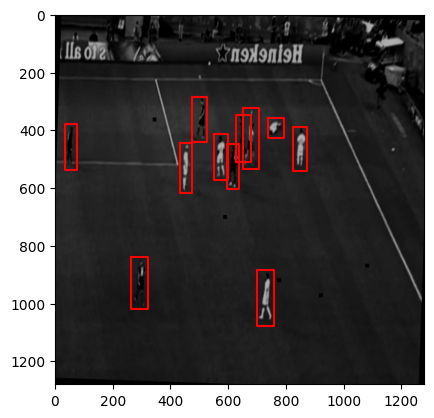

In [ ]:
show_random_image_with_labels("train")

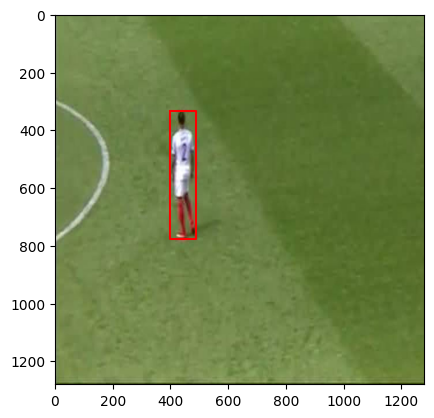

In [ ]:
show_random_image_with_labels("valid")

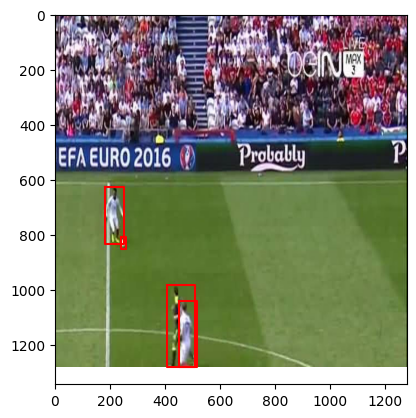

In [ ]:
show_random_image_with_labels("test")

In [ ]:
def visualize_labels(split: str):
    paths = glob.glob(f"dataset/{split}/labels/*.txt")
    labels = [read_label_file(path) for path in paths]
    class_ids = [label.class_id for image_labels in labels for label in image_labels]

    _, _, bars = plt.hist(class_ids)
    plt.bar_label(bars)
    plt.xticks(range(len(class_names)), class_names)
    plt.show()

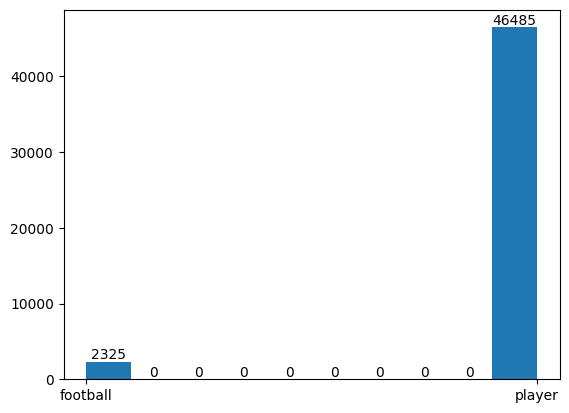

In [ ]:
visualize_labels("train")

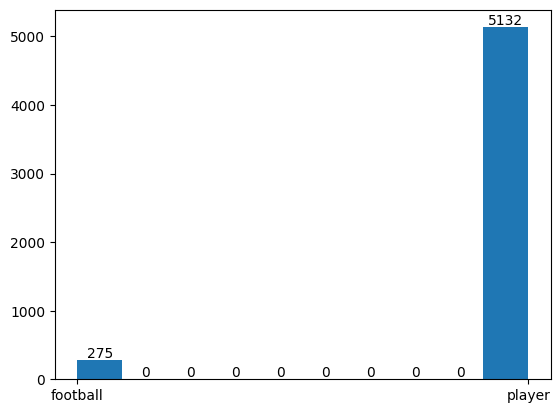

In [ ]:
visualize_labels("valid")

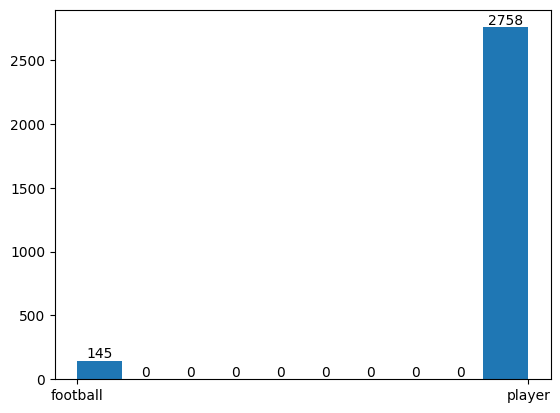

In [ ]:
visualize_labels("test")

#Training

In [ ]:
!mkdir /content/football_players_detection/football_players_detection/test/images-preprocessed

In [ ]:
IMAGE_SIZE = 640

for image_path in glob.glob("/content/football_players_detection/football_players_detection/test/images/*.jpg"):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    filename = os.path.basename(image_path)
    cv2.imwrite(f"/content/football_players_detection/football_players_detection/test/images-preprocessed/{filename}", image)

In [ ]:
#Load the model
model = YOLO("yolo26n.pt")

#Train the model
results = model.train(data="/content/football_players_detection/football_players_detection/data.yaml", epochs=50, imgsz= 640)

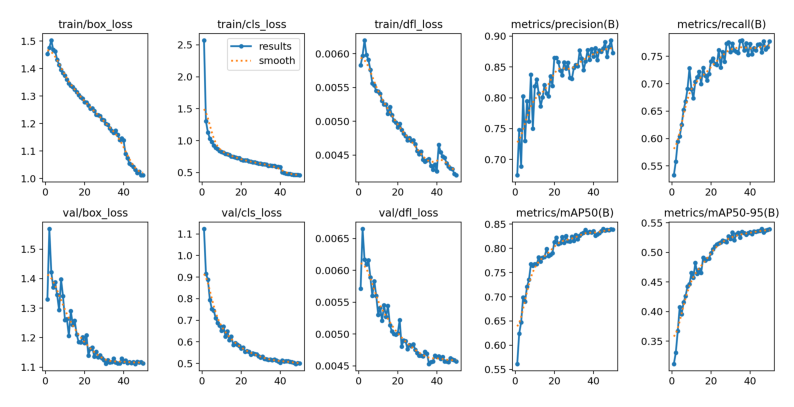

In [ ]:
image = read_image('/content/runs/detect/train/results.png')
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.show()

# Evaluate The Model

In [ ]:
#Evaluate the model on test data
results = model.val(data="/content/football_players_detection/football_players_detection/data.yaml")

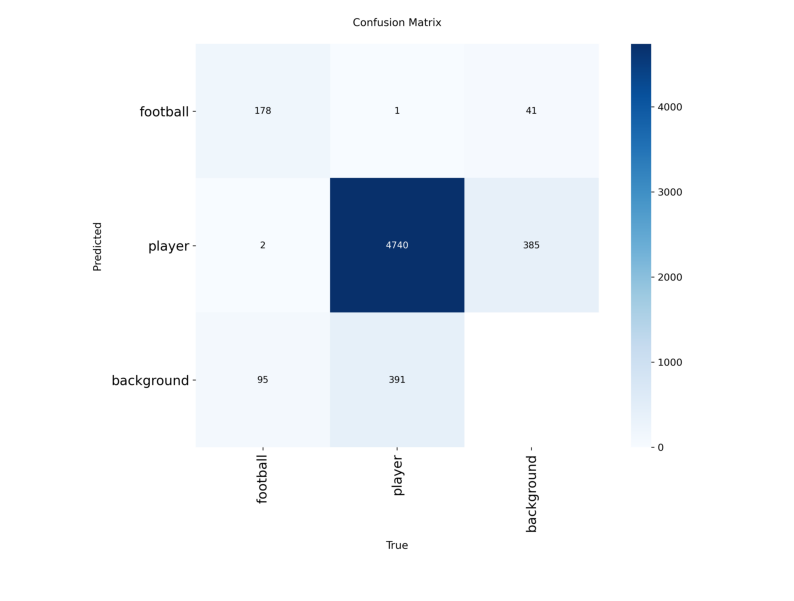

In [ ]:
image = read_image('/content/runs/detect/val/confusion_matrix.png')
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.show()

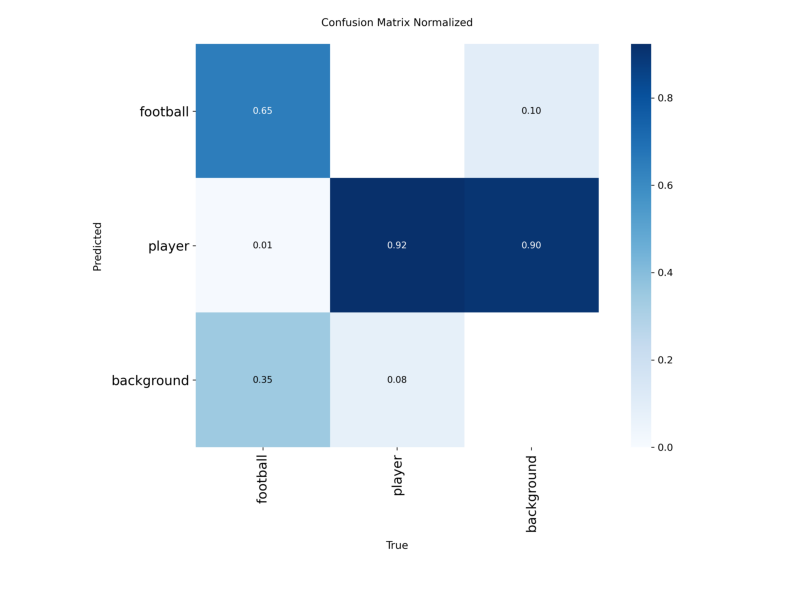

In [ ]:
image = read_image('/content/runs/detect/val/confusion_matrix_normalized.png')
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:
# Run batched inference on a list of images
results = model('/content/football_players_detection/football_players_detection/test/images')  # return a list of Results objects

# Process results list
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    result.show()  # display to screen
    result.save(filename="result.jpg")  # save to disk


image 1/520 /content/football_players_detection/football_players_detection/test/images/102_pp_jpg.rf.04ca2f20dbf39c3be706d2f14c45bc31.jpg: 640x640 1 football, 4 players, 28.5ms
image 2/520 /content/football_players_detection/football_players_detection/test/images/102_pp_jpg.rf.0ffb40112e9b898eb311651f97b1cf6a.jpg: 640x640 4 players, 31.6ms
image 3/520 /content/football_players_detection/football_players_detection/test/images/102_pp_jpg.rf.7c841f548216975cab8b16676ff2810e.jpg: 640x640 7 players, 23.3ms
image 4/520 /content/football_players_detection/football_players_detection/test/images/102_pp_jpg.rf.7dd2b04546f77f2321ef7c67d7e109d2.jpg: 640x640 14 players, 42.9ms
image 5/520 /content/football_players_detection/football_players_detection/test/images/105_pp_jpg.rf.191815498deea9d88603b9044fa159a3.jpg: 640x640 4 players, 10.0ms
image 6/520 /content/football_players_detection/football_players_detection/test/images/105_pp_jpg.rf.a8007d83f07ddadfd87274a702d32216.jpg: 640x640 10 players, 47

In [ ]:
result[:5]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'football', 1: 'player'}
obb: None
orig_img: array([[[ 22, 155,  99],
        [ 22, 155,  99],
        [ 22, 154, 101],
        ...,
        [  0,  14,   0],
        [  7,  16,   3],
        [  8,  15,   2]],

       [[ 22, 155,  99],
        [ 22, 155,  99],
        [ 22, 154, 101],
        ...,
        [  0,  14,   0],
        [  7,  16,   3],
        [  8,  15,   2]],

       [[ 22, 154, 101],
        [ 22, 154, 101],
        [ 22, 154, 101],
        ...,
        [  0,  14,   0],
        [  7,  16,   3],
        [  8,  15,   2]],

       ...,

       [[  0,  75,  41],
        [  0,  75,  41],
        [  0,  75,  41],
        ...,
        [  0,   9,   0],
        [ 14,  19,  10],
        [ 12,  15,   6]],

       [[  0,  74,  40],
        [  0,  74,  40],
        [  0,  74,  40],
        ...,
        [  0,  10,   0],
        [ 14,  19,  10]

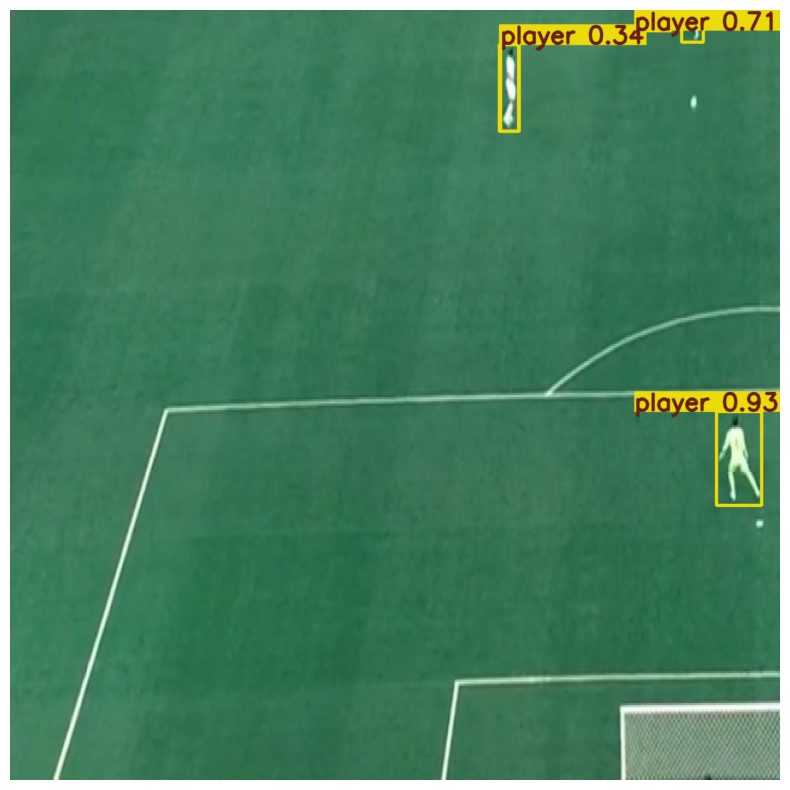

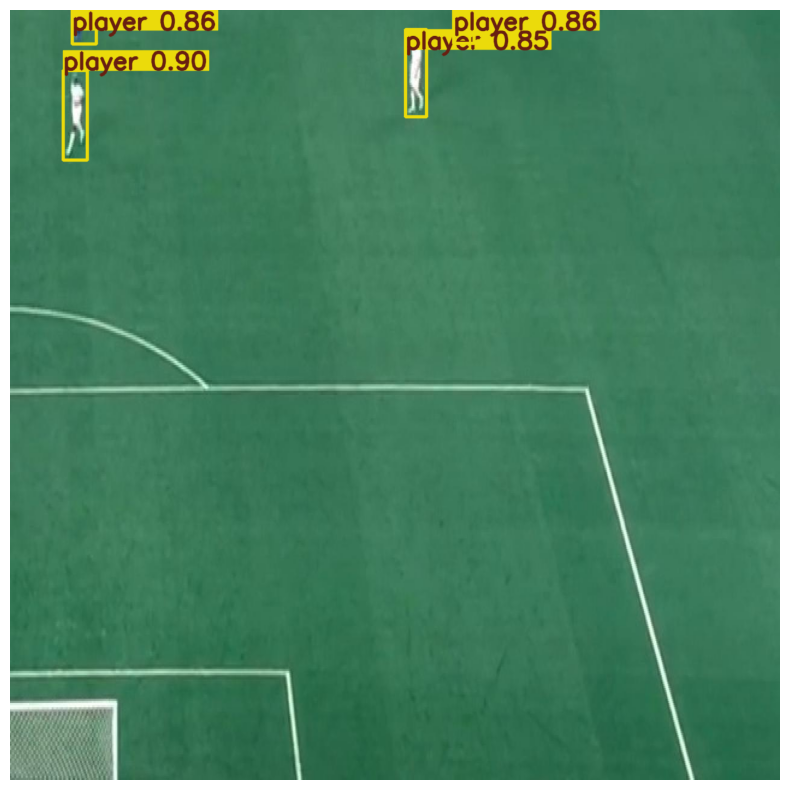

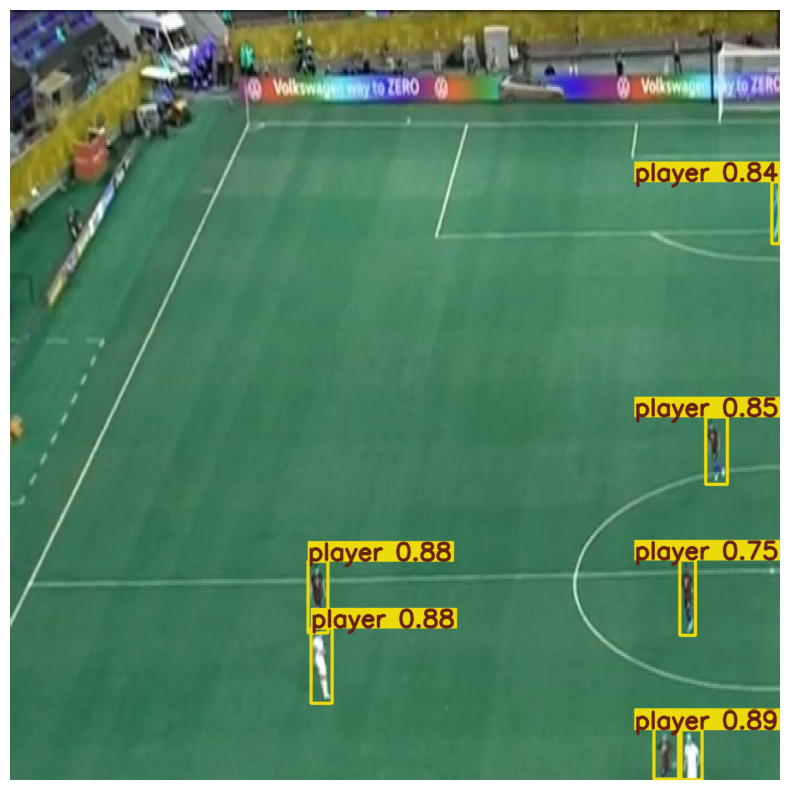

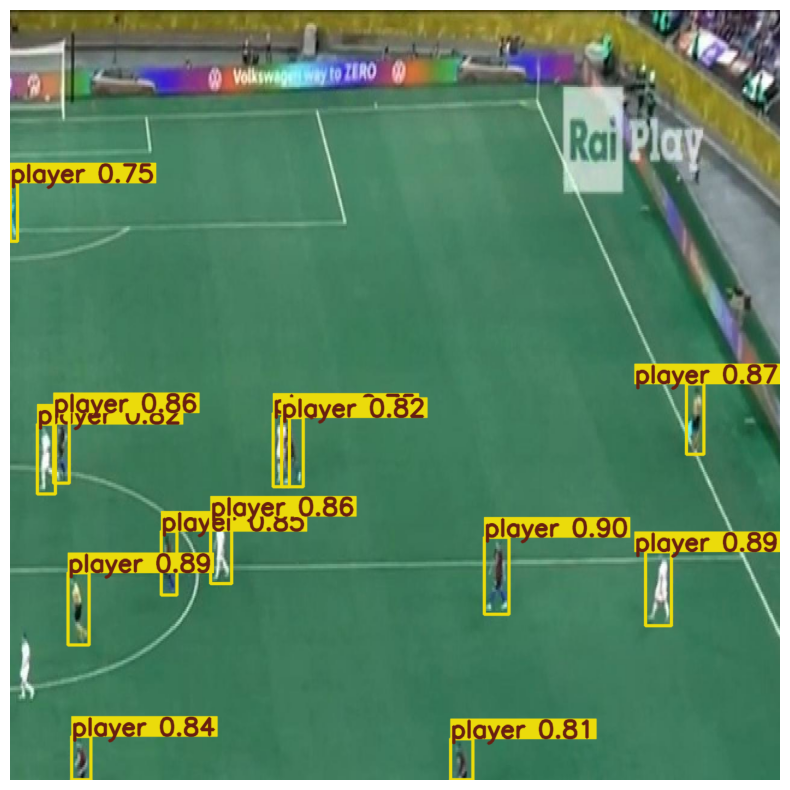

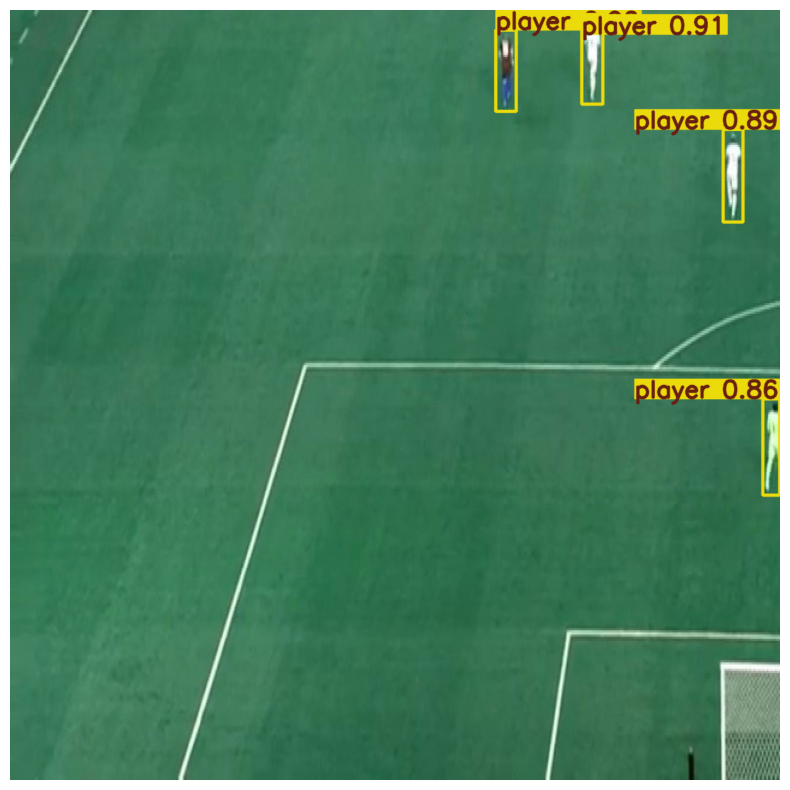

In [ ]:
for result in results[:5]:
  annotated_image = result.plot()
  plt.figure(figsize=(10, 10))
  plt.imshow(annotated_image)
  plt.axis('off')
  plt.show()

In [ ]:
# Load video
video_path = "/content/6079623-sd_640_360_25fps.mp4"

#Run the model to detect and track players in the video
model.track(
    source= video_path,
    save=True,        # saves output video
    persist=True,
    conf=0.25
)